# 03 — Entraînement & évaluation POC

On recharge le modèle entraîné (`src/train_jepa.py`, checkpoint `data/processed/jepa.pt`) et on répond à **la** question : le JEPA *comprend-il* les trajectoires, ou a-t-il trouvé un raccourci ?

Trois angles :
1. **Santé de l'entraînement** (courbes, anti-effondrement)
2. **Retrieval** — la prédiction retrouve-t-elle le futur ? (films + chunks, vs baselines)
3. **Probe** — l'espace latent code-t-il le contenu ? (genome R², genres AUC, UMAP)

> ⚠️ Pré-requis : avoir lancé `./.venv/bin/python -m src.train_jepa` (checkpoint présent).

In [70]:
import importlib; from src import evaluate_jepa as ev; importlib.reload(ev)


<module 'src.evaluate_jepa' from '/Users/julesvidegrain/Desktop/Projets GitHub/Customer behavior/src/evaluate_jepa.py'>

In [71]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data_prep import load_all, PROCESSED
from src.train_jepa import load_model
from src import evaluate_jepa as ev

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
EVAL_USERS = 8000        # échantillon de users de test (estimation stable, rapide)
print("device:", DEVICE)

device: mps


## 1 — Santé de l'entraînement

On vérifie que la perte descend **et** que `pred_std` (train et val) ne s'effondre pas vers 0.

,epoch,loss,inv,pred_std,val_chunk_std,val_chunk_cos
0,1,23.2440,0.5772,0.3741,1.0434,0.0637
1,2,28.7223,0.9083,0.5347,1.0538,0.0554
2,3,29.8960,0.9840,0.5912,1.0345,0.0683
3,4,29.4476,0.9806,0.6202,1.0414,0.0689
4,5,28.8485,0.9664,0.6397,1.0412,0.0676
5,6,28.3428,0.9526,0.6521,1.0288,0.0687
6,7,27.9846,0.9427,0.6607,1.0468,0.0648
7,8,27.7346,0.9359,0.6666,1.0421,0.0681
8,9,27.5356,0.9301,0.6704,1.0365,0.0657
9,10,27.3726,0.9248,0.6723,1.0402,0.0602


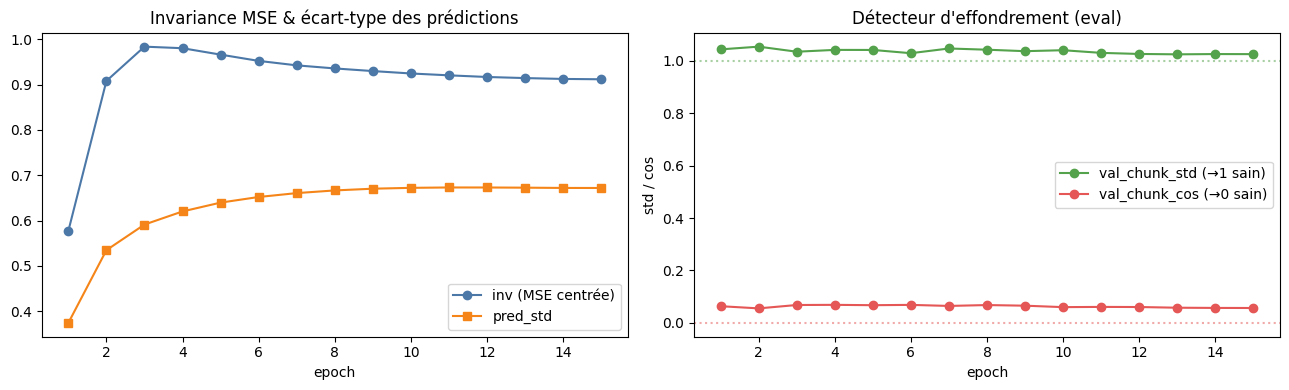

In [72]:
history = json.load(open(PROCESSED / "train_history.json"))
hist = pd.DataFrame(history)
display(hist[["epoch", "loss", "inv", "pred_std", "val_chunk_std", "val_chunk_cos"]].round(4))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
# invariance = MSE centrée (ẑ_t vs z_{t+1}) ; ATTENTION : non normalisée, donc
# gonflée mécaniquement quand VICReg augmente l'échelle des cibles -> à lire avec pred_std.
a1.plot(hist["epoch"], hist["inv"], marker="o", color="#4C78A8", label="inv (MSE centrée)")
a1.plot(hist["epoch"], hist["pred_std"], marker="s", color="#F58518", label="pred_std")
a1.set(title="Invariance MSE & écart-type des prédictions", xlabel="epoch"); a1.legend()

# détecteur d'effondrement FIABLE (mode eval) : std ~1 = sain / 0 = collapse ;
# cos ~0 = sain (chunks orthogonaux) / ~1 = collapse (tout aligné).
a2.plot(hist["epoch"], hist["val_chunk_std"], marker="o", color="#54A24B", label="val_chunk_std (→1 sain)")
a2.plot(hist["epoch"], hist["val_chunk_cos"], marker="o", color="#E45756", label="val_chunk_cos (→0 sain)")
a2.axhline(1.0, color="#54A24B", ls=":", alpha=0.5)
a2.axhline(0.0, color="#E45756", ls=":", alpha=0.5)
a2.set(title="Détecteur d'effondrement (eval)", xlabel="epoch", ylabel="std / cos"); a2.legend()
plt.tight_layout(); plt.show()

In [73]:
sequences, genome, maps = load_all()
model = load_model(DEVICE)
eval_sub = sequences.sample(EVAL_USERS, random_state=0).reset_index(drop=True)
print(f"modèle rechargé (epoch {torch.load(PROCESSED/'jepa.pt', map_location='cpu', weights_only=False).get('epoch','?')})")

item_bank = ev.build_item_bank(model, DEVICE)
zhat, H, T = ev.encode_eval(model, eval_sub, DEVICE, split="test")
print("item bank:", tuple(item_bank.shape), "| requêtes test:", tuple(zhat.shape))

modèle rechargé (epoch 15)
item bank: (10346, 128) | requêtes test: (7999, 128)


In [74]:
# DIAGNOSTIC CLÉ : le cosine de 0.97 est-il impressionnant ou trivial ?
diag = ev.representation_diagnostics(model, sequences, DEVICE)
print(f"Similarité cosine moyenne entre 2 chunks au hasard : {diag['mean_pairwise_cos_targets']:.3f}")
print(f"Anisotropie (norme direction moyenne, 1=tout aligné) : {diag['anisotropy_mean_dir_norm']:.3f}")
print()
print("Lecture :")
print("  - si sim ~0.9 -> l'espace des cibles est ÉTROIT : cosine 0.97 = TRIVIAL (raccourci)")
print("  - si sim ~0.2 -> cosine 0.97 = vraie prédiction discriminante")

Similarité cosine moyenne entre 2 chunks au hasard : 0.058
Anisotropie (norme direction moyenne, 1=tout aligné) : 0.245

Lecture :
  - si sim ~0.9 -> l'espace des cibles est ÉTROIT : cosine 0.97 = TRIVIAL (raccourci)
  - si sim ~0.2 -> cosine 0.97 = vraie prédiction discriminante


## 2 — Retrieval

**Films** : la représentation prédite `ẑ` retrouve-t-elle les films du vrai prochain chunk, mieux que la simple **popularité** ?

In [75]:
rf = ev.retrieval_films(zhat, item_bank, T, sequences, maps, ks=(10, 20, 50, 100), device=DEVICE)
tbl = pd.DataFrame({"JEPA": rf["recall_model"], "Popularité": rf["recall_pop"]})
tbl.index.name = "Recall@K"
display((tbl * 100).round(2).astype(str) + " %")
print("Rang médian du 1er bon film (JEPA) :", rf["median_rank_model"])

,JEPA,Popularité
Recall@K,,
10,41.29 %,11.18 %
20,48.77 %,17.7 %
50,58.98 %,30.97 %
100,67.7 %,43.37 %


Rang médian du 1er bon film (JEPA) : 22.0


**Chunks** : plus proche voisin de `ẑ` parmi les vrais chunks de test, vs baseline **répétition** (redonner le dernier chunk vu).

In [76]:
rc = ev.retrieval_chunks(model, zhat, eval_sub, maps, DEVICE, ks=(1, 5, 10, 20))
tblc = pd.DataFrame({"JEPA": rc["recall_model"], "Répétition": rc["recall_repeat"]})
tblc.index.name = f"Recall@K (parmi {rc['n']} chunks)"
display((tblc * 100).round(2).astype(str) + " %")

,JEPA,Répétition
Recall@K (parmi 7999 chunks),,
1,3.0 %,0.08 %
5,9.78 %,0.33 %
10,14.98 %,0.76 %
20,21.3 %,1.7 %


### Baseline forte : kNN-contenu (model-free)

La popularité et la répétition sont des planchers bas. Vraie question : le JEPA
bat-il une heuristique **de contenu** qui prédit « encore la même chose » ?
`content_knn_retrieval` classe films et chunks par similarité **genome brute** au
**dernier chunk vu** — le signal court-portée du notebook 04, sans rien apprendre.
Même échantillon/protocole que le JEPA.

In [77]:
ck = ev.content_knn_retrieval(eval_sub, genome, maps, device=DEVICE)

film = pd.DataFrame({"JEPA": rf["recall_model"], "kNN-contenu": ck["recall_film"],
                     "Popularité": rf["recall_pop"]})
film.index.name = "Recall@K — films"
display((film * 100).round(2).astype(str) + " %")
print(f"Rang médian 1er bon film : JEPA {rf['median_rank_model']:.0f}  |  "
      f"kNN-contenu {ck['median_rank_film']:.0f}")

chunk = pd.DataFrame({"JEPA": rc["recall_model"], "kNN-contenu": ck["recall_chunk"],
                      "Répétition": rc["recall_repeat"]})
chunk.index.name = f"Recall@K — chunks (parmi {ck['n']})"
display((chunk * 100).round(2).astype(str) + " %")

,JEPA,kNN-contenu,Popularité
Recall@K — films,,,
10,41.29 %,8.13 %,11.18 %
20,48.77 %,13.23 %,17.7 %
50,58.98 %,23.88 %,30.97 %
100,67.7 %,34.67 %,43.37 %


Rang médian 1er bon film : JEPA 22  |  kNN-contenu 100


,JEPA,kNN-contenu,Répétition
Recall@K — chunks (parmi 7999),,,
1,3.0 %,0.36 %,0.08 %
5,9.78 %,1.76 %,0.33 %
10,14.98 %,2.96 %,0.76 %
20,21.3 %,4.71 %,1.7 %


## 3 — Probes de contenu

L'état de contexte `hₜ` encode-t-il le **contenu** du prochain chunk ? (régression genome R², classification genres AUC)

In [78]:
r2 = ev.probe_genome(H, T, genome)
auc, genres_used = ev.probe_genres(H, T, maps)
print(f"Probe genome (R², variance expliquée du genome futur) : {r2:.3f}")
print(f"Probe genres (AUC macro, {len(genres_used)} genres)          : {auc:.3f}")
print("  (R² et AUC ~0 / 0.5 = l'espace n'encode PAS le contenu ; élevé = il le capte)")

Probe genome (R², variance expliquée du genome futur) : 0.258
Probe genres (AUC macro, 12 genres)          : 0.684
  (R² et AUC ~0 / 0.5 = l'espace n'encode PAS le contenu ; élevé = il le capte)


**UMAP** — projection 2D des représentations de chunk, colorée par genre dominant. Si l'espace est structuré, les genres se regroupent.

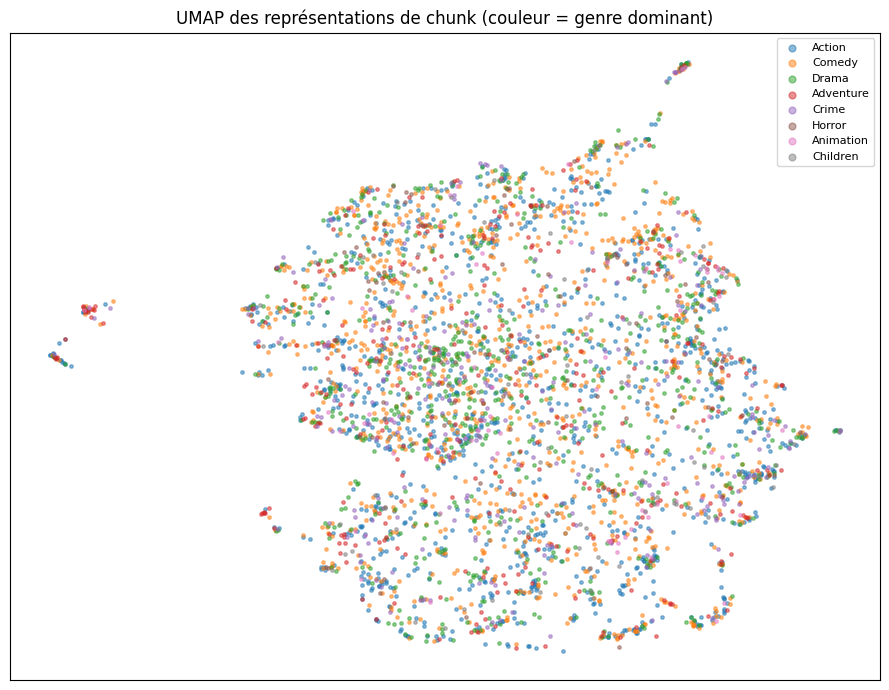

In [79]:
proj, gen = ev.umap_chunks(model, sequences, maps, DEVICE, n_chunks=4000)
gen = np.array(gen)
top = pd.Series(gen).value_counts().head(8).index.tolist()
plt.figure(figsize=(9, 7))
for g in top:
    m = gen == g
    plt.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.5, label=g)
plt.legend(markerscale=2, fontsize=8, loc="best")
plt.title("UMAP des représentations de chunk (couleur = genre dominant)")
plt.xticks([]); plt.yticks([]); plt.tight_layout(); plt.show()

**PCA (contrôle linéaire)** — même échantillon de chunks, projection PCA 2D (déterministe, sans réglage). Si les genres se séparent déjà ici, la structure est *linéairement* lisible (signal fort) ; sinon, la non-linéarité de l'UMAP était nécessaire. La variance expliquée par les 2 axes indique combien la PCA capture.

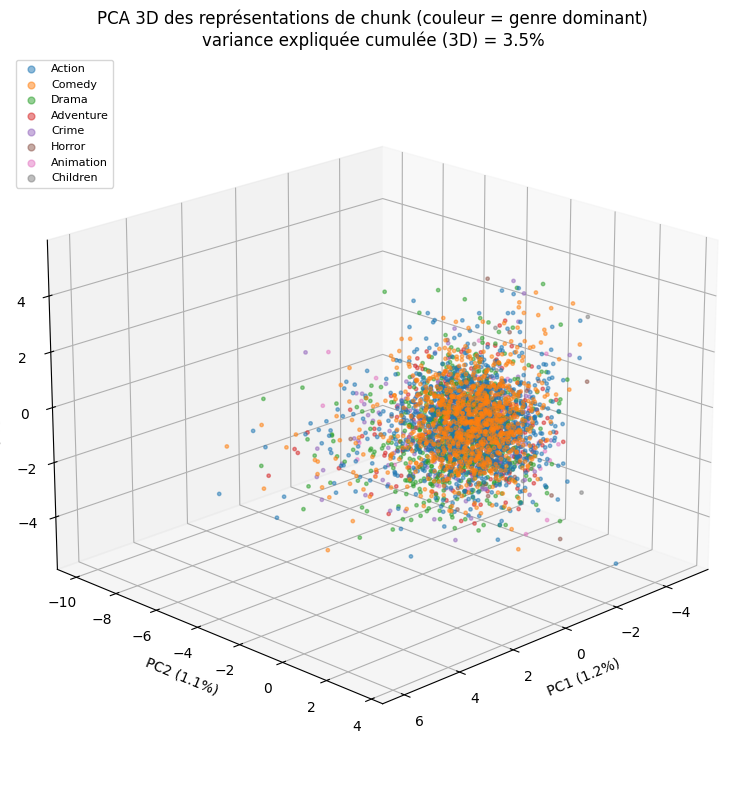

In [80]:
# PCA 3D (contrôle linéaire). Astuce : %matplotlib widget pour tourner la vue.
proj_p, gen_p, evr = ev.pca_chunks(model, sequences, maps, DEVICE, n_chunks=4000, n_components=3)
gen_p = np.array(gen_p)
top_p = pd.Series(gen_p).value_counts().head(8).index.tolist()

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
for g in top_p:
    m = gen_p == g
    ax.scatter(proj_p[m, 0], proj_p[m, 1], proj_p[m, 2], s=6, alpha=0.5, label=g)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({evr[2]*100:.1f}%)")
ax.set_title("PCA 3D des représentations de chunk (couleur = genre dominant)\n"
             f"variance expliquée cumulée (3D) = {evr[:3].sum()*100:.1f}%")
ax.legend(markerscale=2, fontsize=8, loc="upper left")
ax.view_init(elev=20, azim=45)
plt.tight_layout(); plt.show()

## Verdict POC (à lire honnêtement)

Grille de lecture :

- **Anti-effondrement** : `pred_std` reste franchement > 0 → le modèle n'a pas triché.
- **Retrieval films vs popularité** : si JEPA **> popularité**, il a appris quelque chose d'utile au-delà du « recommander les blockbusters ». S'il reste **sous** la popularité, le signal séquentiel appris est faible (fréquent sur MovieLens à cause des rafales de notation).
- **Retrieval chunks vs répétition** : si JEPA **> répétition**, il anticipe un changement plutôt que de recopier le passé immédiat.
- **Probes** : R²/AUC élevés → l'espace latent code le contenu futur = une vraie forme de *compréhension* de trajectoire, même si le retrieval brut est modeste.

Le cas le plus instructif d'une POC : **probes bons mais retrieval ≈ popularité** → le JEPA capte la *structure* du goût sans battre une heuristique triviale de reco. À interpréter ensemble.